In [2]:
import sys
sys.path.append('../')

import numpy as np
import pandas as pd
import importlib
import matplotlib.pyplot as plt

import env.trading_env as te1
import env.trading_env_v2 as te2
import env.trading_env_v3 as te3
import features.feature_engineering as fe
import backtest.backtest as bt

importlib.reload(te1)
importlib.reload(te2)
importlib.reload(te3)
importlib.reload(fe)
importlib.reload(bt)

from stable_baselines3 import PPO, A2C

#
df = pd.read_excel('../data/data.xlsx', skiprows=6, header=0)
df.columns = ['date', 'gold', 'silver', 'copper']
df = df[pd.to_datetime(df['date'], errors='coerce').notna()]
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)


features_final = fe.build_features(df)


train = features_final[features_final.index <= '2023-12-31']
test = features_final[features_final.index >= '2024-01-01']
price_train = df[df.index.isin(train.index)]
price_test = df[df.index.isin(test.index)]

print(f"Train: {len(train)}days, Test: {len(test)}days")

Train: 2592days, Test: 485days


In [3]:
# 加载模型
ppo_v2 = PPO.load("../agents/ppo_v2_1m.zip")
a2c_v2 = A2C.load("../agents/a2c_v2_1m.zip")
ppo_v3 = PPO.load("../agents/ppo_v3_1.2m")
a2c_v3 = A2C.load("../agents/a2c_v3_1.4m")

# 初始化test环境
test_env_ppo_v2 = te2.MetalTradingEnvV2(test, price_test)
test_env_a2c_v2 = te2.MetalTradingEnvV2(test, price_test)
test_env_ppo_v3 = te3.MetalTradingEnvV3(test, price_test)
test_env_a2c_v3 = te3.MetalTradingEnvV3(test, price_test)
test_env_ew = te2.MetalTradingEnvV2(test, price_test)
test_env_bh = te2.MetalTradingEnvV2(test, price_test)

# 运行backtest
print("Running PPO V2...")
ppo_v2_results = bt.run_agent(ppo_v2, test_env_ppo_v2)

print("Running A2C V2...")
a2c_v2_results = bt.run_agent(a2c_v2, test_env_a2c_v2)

print("Running PPO V3...")
ppo_v3_results = bt.run_agent(ppo_v3, test_env_ppo_v3)

print("Running A2C V3...")
a2c_v3_results = bt.run_agent(a2c_v3, test_env_a2c_v3)

print("Running Equal Weight...")
ew_values = bt.run_equal_weight(test_env_ew)

print("Running Buy and Hold...")
bh_values = bt.run_buy_and_hold(test_env_bh)

# 原始资产归一化
price_test_normalized = price_test / price_test.iloc[0]

print("Done!")

Running PPO V2...
Running A2C V2...
Running PPO V3...
Running A2C V3...
Running Equal Weight...
Running Buy and Hold...
Done!


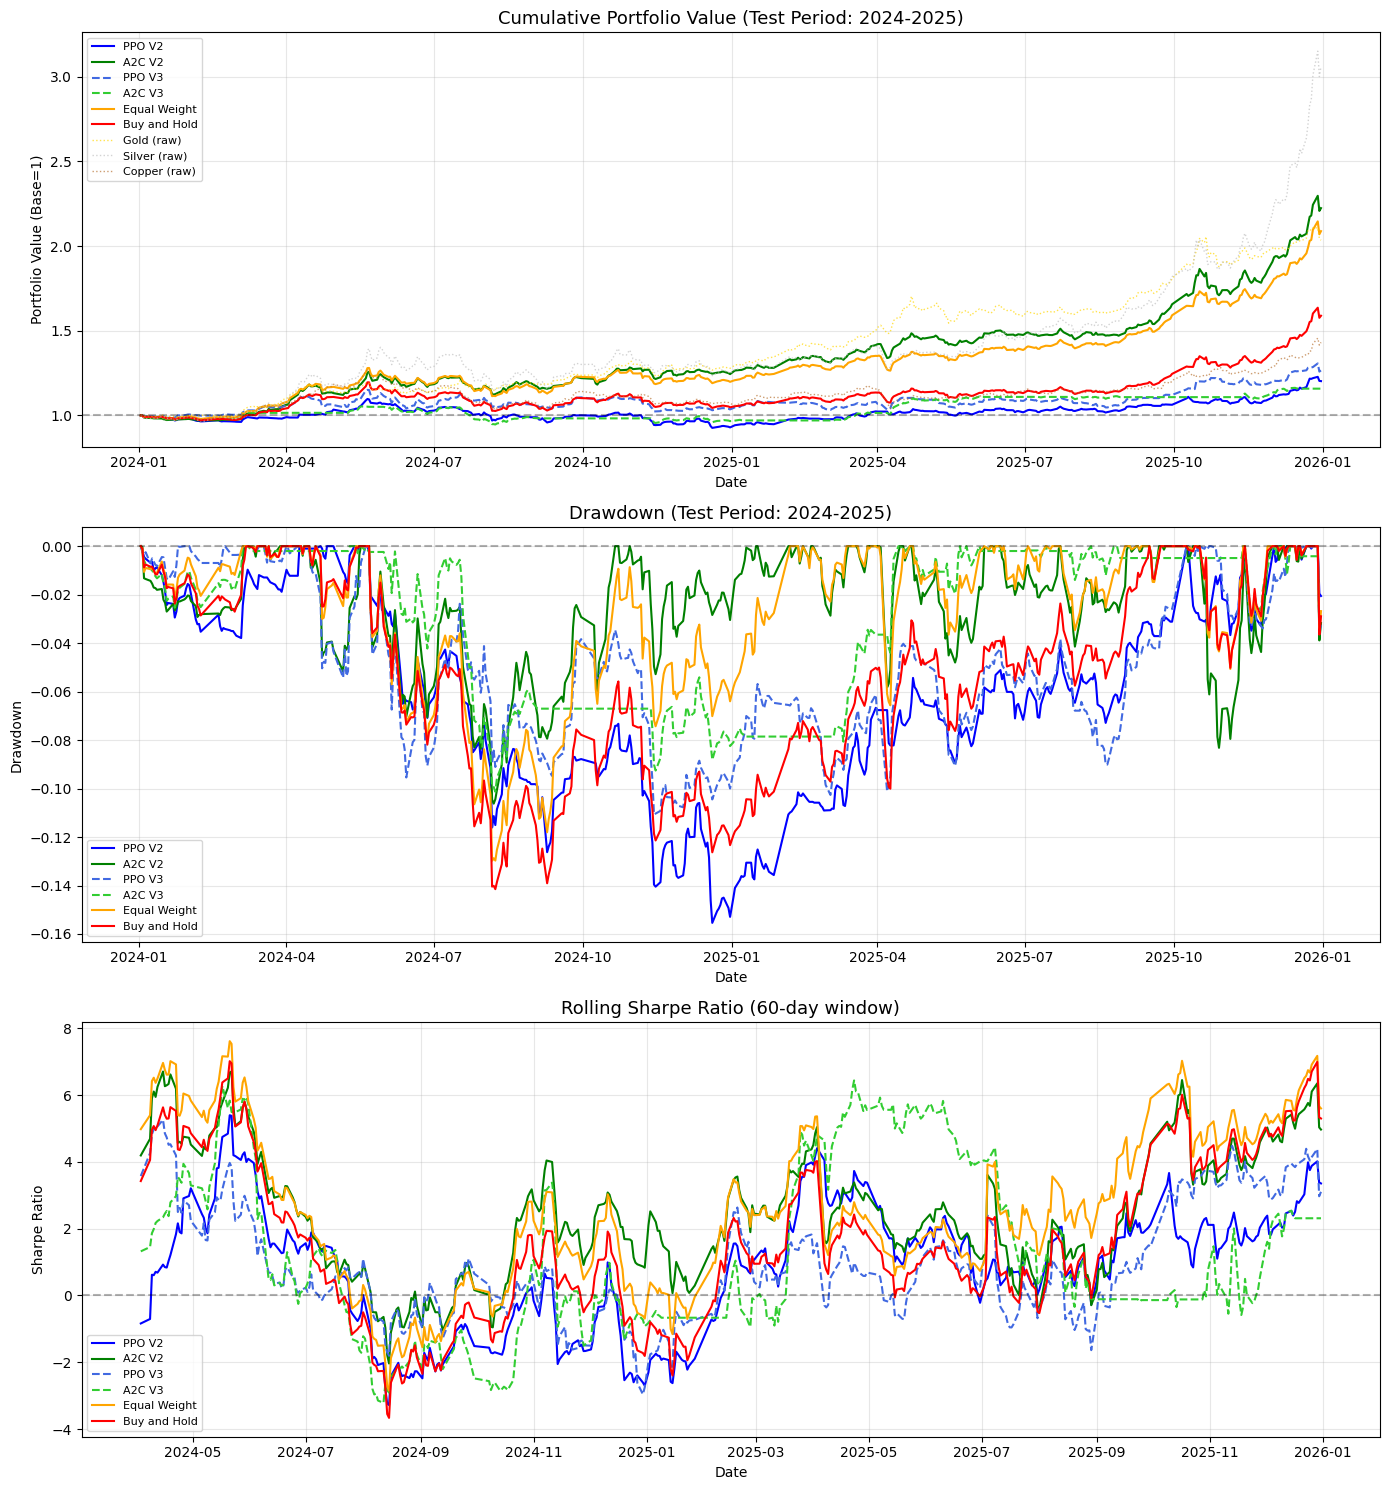

In [4]:
dates = test.index

fig, axes = plt.subplots(3, 1, figsize=(14, 15))

# ── 图1：累计收益曲线 ──
ax1 = axes[0]

strategies = {
    'PPO V2': ppo_v2_results['portfolio_values'],
    'A2C V2': a2c_v2_results['portfolio_values'],
    'PPO V3': ppo_v3_results['portfolio_values'],
    'A2C V3': a2c_v3_results['portfolio_values'],
    'Equal Weight': ew_values,
    'Buy and Hold': bh_values,
}

colors = {
    'PPO V2': 'blue',
    'A2C V2': 'green',
    'PPO V3': 'royalblue',
    'A2C V3': 'limegreen',
    'Equal Weight': 'orange',
    'Buy and Hold': 'red',
}

linestyles = {
    'PPO V2': '-',
    'A2C V2': '-',
    'PPO V3': '--',
    'A2C V3': '--',
    'Equal Weight': '-',
    'Buy and Hold': '-',
}

for name, values in strategies.items():
    ax1.plot(dates, values, 
             color=colors[name], 
             linestyle=linestyles[name],
             linewidth=1.5, label=name)

# 原始资产
asset_colors = {'gold': '#FFD700', 'silver': '#C0C0C0', 'copper': '#B87333'}
for asset in ['gold', 'silver', 'copper']:
    ax1.plot(dates, price_test_normalized[asset],
             color=asset_colors[asset], linewidth=1, 
             linestyle=':', alpha=0.7, label=f'{asset.capitalize()} (raw)')

ax1.axhline(y=1, color='black', linestyle='--', alpha=0.3)
ax1.set_title('Cumulative Portfolio Value (Test Period: 2024-2025)', fontsize=13)
ax1.set_xlabel('Date')
ax1.set_ylabel('Portfolio Value (Base=1)')
ax1.legend(loc='upper left', fontsize=8)
ax1.grid(alpha=0.3)

# ── 图2：Drawdown曲线 ──
ax2 = axes[1]

for name, values in strategies.items():
    peak = np.maximum.accumulate(values)
    drawdown = (values - peak) / peak
    ax2.plot(dates, drawdown,
             color=colors[name],
             linestyle=linestyles[name],
             linewidth=1.5, label=name)

ax2.axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax2.set_title('Drawdown (Test Period: 2024-2025)', fontsize=13)
ax2.set_xlabel('Date')
ax2.set_ylabel('Drawdown')
ax2.legend(loc='lower left', fontsize=8)
ax2.grid(alpha=0.3)

# ── 图3：Rolling Sharpe（60天）──
ax3 = axes[2]

for name, values in strategies.items():
    returns = np.diff(values) / values[:-1]
    rolling_mean = pd.Series(returns).rolling(60).mean()
    rolling_std = pd.Series(returns).rolling(60).std()
    rolling_sharpe = rolling_mean / (rolling_std + 1e-8) * np.sqrt(252)
    ax3.plot(dates[1:], rolling_sharpe,
             color=colors[name],
             linestyle=linestyles[name],
             linewidth=1.5, label=name)

ax3.axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax3.set_title('Rolling Sharpe Ratio (60-day window)', fontsize=13)
ax3.set_xlabel('Date')
ax3.set_ylabel('Sharpe Ratio')
ax3.legend(loc='lower left', fontsize=8)
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../notebooks/results_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

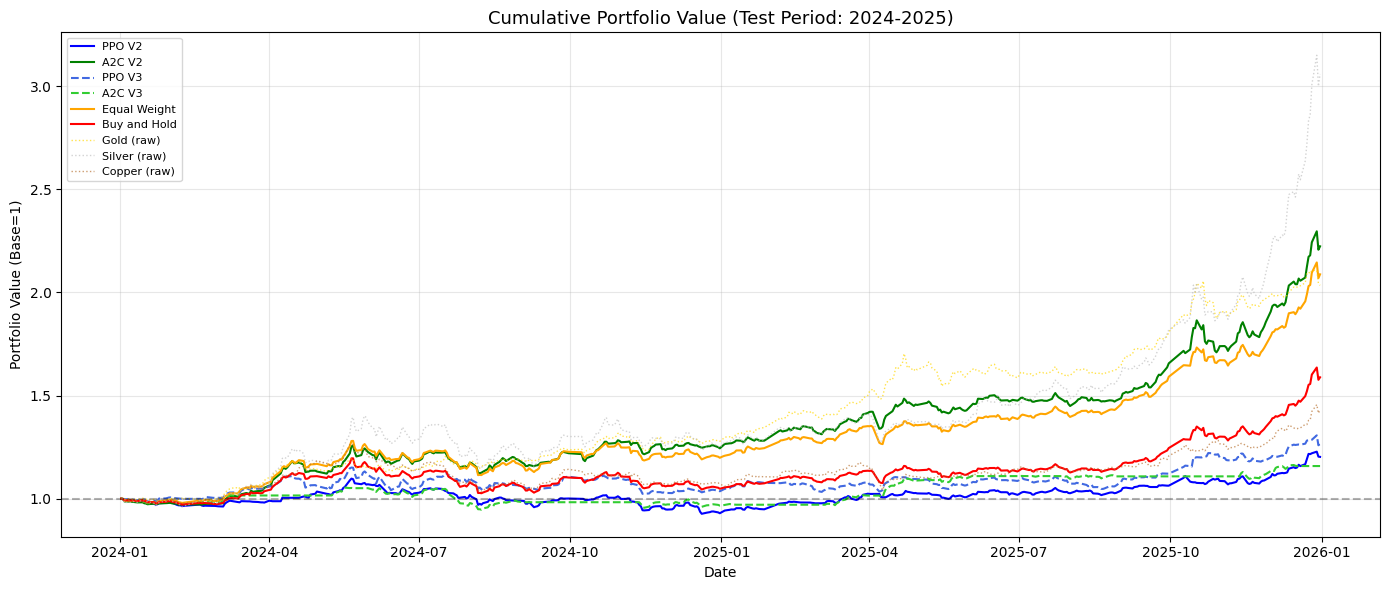

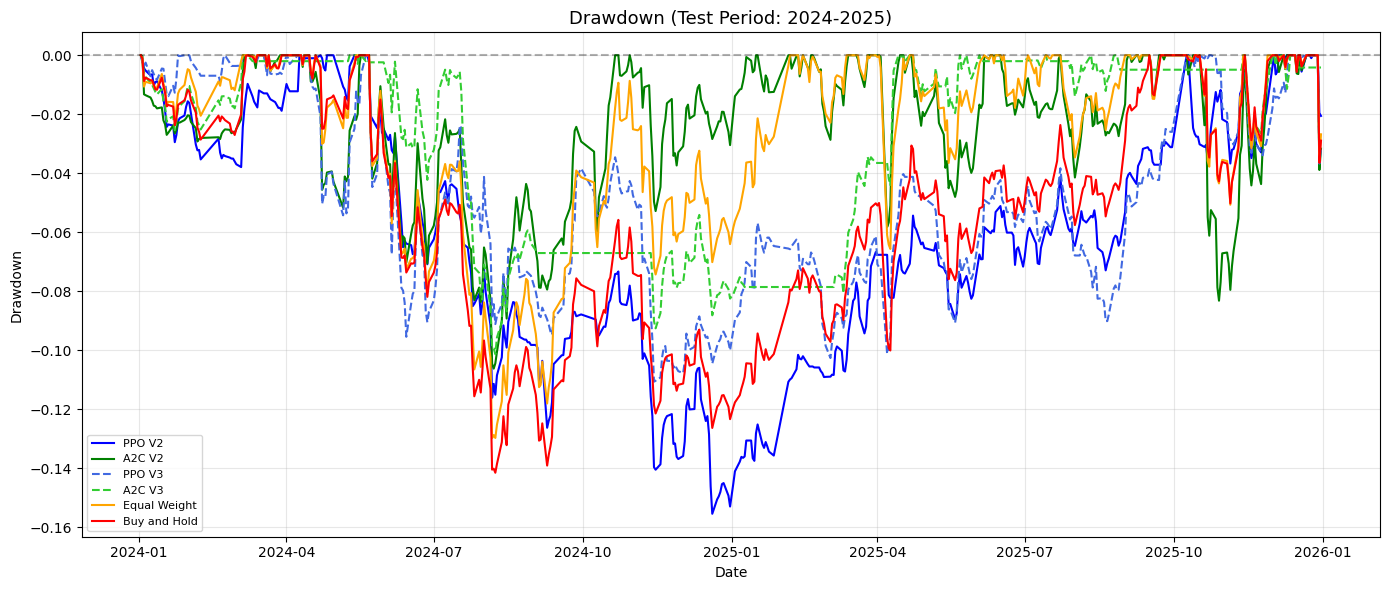

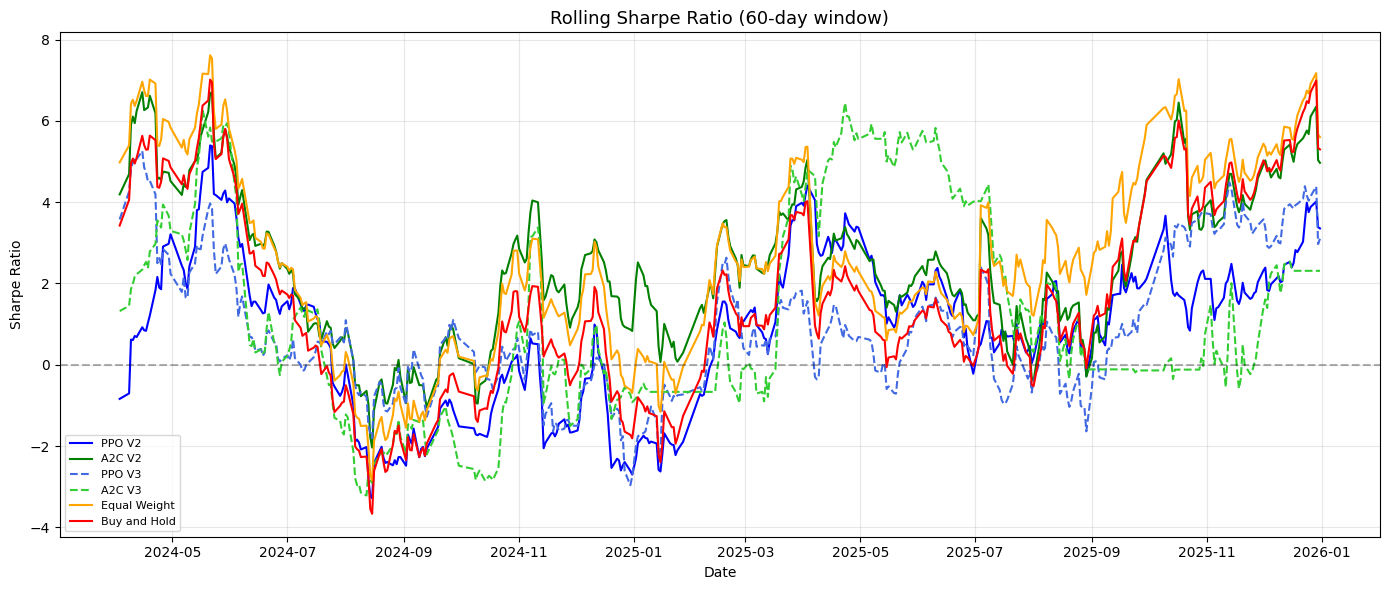

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

dates = test.index

# ========== 图1：累计收益曲线 ==========
fig1, ax1 = plt.subplots(figsize=(14, 6))

strategies = {
    'PPO V2': ppo_v2_results['portfolio_values'],
    'A2C V2': a2c_v2_results['portfolio_values'],
    'PPO V3': ppo_v3_results['portfolio_values'],
    'A2C V3': a2c_v3_results['portfolio_values'],
    'Equal Weight': ew_values,
    'Buy and Hold': bh_values,
}

colors = {
    'PPO V2': 'blue',
    'A2C V2': 'green',
    'PPO V3': 'royalblue',
    'A2C V3': 'limegreen',
    'Equal Weight': 'orange',
    'Buy and Hold': 'red',
}

linestyles = {
    'PPO V2': '-',
    'A2C V2': '-',
    'PPO V3': '--',
    'A2C V3': '--',
    'Equal Weight': '-',
    'Buy and Hold': '-',
}

for name, values in strategies.items():
    ax1.plot(dates, values, 
             color=colors[name], 
             linestyle=linestyles[name],
             linewidth=1.5, label=name)

# 原始资产
asset_colors = {'gold': '#FFD700', 'silver': '#C0C0C0', 'copper': '#B87333'}
for asset in ['gold', 'silver', 'copper']:
    ax1.plot(dates, price_test_normalized[asset],
             color=asset_colors[asset], linewidth=1, 
             linestyle=':', alpha=0.7, label=f'{asset.capitalize()} (raw)')

ax1.axhline(y=1, color='black', linestyle='--', alpha=0.3)
ax1.set_title('Cumulative Portfolio Value (Test Period: 2024-2025)', fontsize=13)
ax1.set_xlabel('Date')
ax1.set_ylabel('Portfolio Value (Base=1)')
ax1.legend(loc='upper left', fontsize=8)
ax1.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('cumulative_portfolio_value.png', dpi=150, bbox_inches='tight')
plt.show()

# ========== 图2：Drawdown曲线 ==========
fig2, ax2 = plt.subplots(figsize=(14, 6))

for name, values in strategies.items():
    peak = np.maximum.accumulate(values)
    drawdown = (values - peak) / peak
    ax2.plot(dates, drawdown,
             color=colors[name],
             linestyle=linestyles[name],
             linewidth=1.5, label=name)

ax2.axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax2.set_title('Drawdown (Test Period: 2024-2025)', fontsize=13)
ax2.set_xlabel('Date')
ax2.set_ylabel('Drawdown')
ax2.legend(loc='lower left', fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('drawdown_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# ========== 图3：Rolling Sharpe（60天）==========
fig3, ax3 = plt.subplots(figsize=(14, 6))

for name, values in strategies.items():
    returns = np.diff(values) / values[:-1]
    rolling_mean = pd.Series(returns).rolling(60).mean()
    rolling_std = pd.Series(returns).rolling(60).std()
    rolling_sharpe = rolling_mean / (rolling_std + 1e-8) * np.sqrt(252)
    ax3.plot(dates[1:], rolling_sharpe,
             color=colors[name],
             linestyle=linestyles[name],
             linewidth=1.5, label=name)

ax3.axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax3.set_title('Rolling Sharpe Ratio (60-day window)', fontsize=13)
ax3.set_xlabel('Date')
ax3.set_ylabel('Sharpe Ratio')
ax3.legend(loc='lower left', fontsize=8)
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('rolling_sharpe_ratio.png', dpi=150, bbox_inches='tight')
plt.show()